# Inferência: identidades ao longo do tempo

Recebe a **pasta de uma sequência** (formato MOTChallenge) e devolve:

1. as **tracks** com identidades consistentes (um id por pessoa, o mesmo do primeiro ao último quadro em que ela aparece);
2. a **contagem de objetos únicos**;
3. um **vídeo** com as identidades coloridas (mesmo id, mesma cor) e um GIF curto para ver aqui no notebook.

**Roda sem retreinar:** carrega o checkpoint do modelo final (`outputs/checkpoints/final_motion_rnn.pt`, GRU de movimento treinado
com teacher forcing, seed 42) e aplica a mesma regra de associação das Partes 1 a 5. Nenhuma linha deste notebook treina nada.

**Contrato da pasta:** `seqinfo.ini` e, para as detecções, `det/det.txt` e/ou as imagens em `img1/`; `gt/gt.txt` é opcional (com GT, saem também as métricas).
Fonte de detecções (`detector="auto"`): `det/det.txt` se existir (detecções públicas, com o limiar de score da Parte 1); senão, se houver imagens, o Faster R-CNN pré-treinado do torchvision
(NMS próprio). Fundo do vídeo: as imagens, se existirem (`data/MOT17/**/img1/`, extraídas do `MOT17.zip`; não são versionadas); senão um fundo vazio.

> Para usar com outra sequência, troque só `SEQUENCE_DIR` na célula abaixo.

In [1]:
# Parâmetros: troque SEQUENCE_DIR pelo caminho da sua sequência
SEQUENCE_DIR = "data/MOT17/train/MOT17-09-SDP"
OUT_DIR = "outputs/inferencia"
SCALE = 0.35          # tamanho do vídeo em relação ao original
MAX_FRAMES = None     # None = a sequência inteira
SHOW_GT = True        # desenha o GT em cinza fino (só se a pasta tiver gt/gt.txt)

import os
from pathlib import Path

# o notebook funciona de qualquer pasta: vai para a raiz do repositório
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pa2" / "config.yaml").exists())
os.chdir(ROOT)
print("raiz do repositório:", ROOT.name)

raiz do repositório: deep-learning-assignment-2


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from pa2.inference import id_color, render_gif, render_video, run_inference, sample_frames

result = run_inference(SEQUENCE_DIR, max_frames=MAX_FRAMES)
seq = result.seq

print(f"sequência : {seq.name} ({seq.info.im_width}x{seq.info.im_height}, {seq.info.frame_rate} fps, {result.n_frames} quadros)")
print(f"detecções : {result.detector_source}; score >= {result.min_conf}; {result.n_detections} detecções usadas")
print(f"modelo    : {result.checkpoint}")
print(f"associação: {result.assoc}")

sequência : MOT17-09 (1920x1080, 30 fps, 525 quadros)
detecções : detecções públicas (SDP, det/det.txt); score >= 0.4; 3607 detecções usadas
modelo    : outputs/checkpoints/final_motion_rnn.pt
associação: {'method': 'greedy', 'iou_threshold': 0.3, 'max_age': 30, 'min_hits': 3}


## Contagem de objetos únicos

A contagem é o **número de ids distintos que o rastreador emitiu**. Ela **superestima** o número de pessoas: toda vez que uma identidade se fragmenta
(oclusão longa, detecção perdida), o rastreador cria um id novo. Na validação o modelo final emite ~1,5 ids por pessoa real (`RELATORY_PART2.md`).
Por isso aparece também a contagem só dos ids vistos em ao menos 10 quadros (descarta ruído de curta duração) e, quando há GT, o número real.

In [3]:
c = result.counts()
print("objetos únicos (ids distintos emitidos):", c["ids_unicos"])
print("  só ids vistos em >= 10 quadros        :", c["ids_unicos_com_10+_quadros"])
print("  pessoas reais (GT)                     :", c["ids_gt"] if c["ids_gt"] is not None else "sem GT nesta pasta")
print(f"  pessoas ativas por quadro (média)      : {c['ativos_por_quadro_media']:.1f}")

if result.metrics:
    m = result.metrics
    print()
    print("métricas contra o GT (implementação própria; IoU 0,5):")
    print(f"  IDF1 {m['idf1']:.3f} | ID switches {m['id_switches']} | fragmentações {m['fragmentations']} | "
          f"ids previstos/verdadeiros {m['n_pred_ids']}/{m['n_gt_ids']} | MOTA {m['mota']:.3f}")
    print("  (n_pred_ids exclui ids que só cobrem distratores, como no benchmark; por isso difere de 'ids distintos emitidos')")

objetos únicos (ids distintos emitidos): 42
  só ids vistos em >= 10 quadros        : 33
  pessoas reais (GT)                     : 26
  pessoas ativas por quadro (média)      : 6.6

métricas contra o GT (implementação própria; IoU 0,5):
  IDF1 0.615 | ID switches 46 | fragmentações 120 | ids previstos/verdadeiros 37/26 | MOTA 0.619
  (n_pred_ids exclui ids que só cobrem distratores, como no benchmark; por isso difere de 'ids distintos emitidos')


## Vídeo com as identidades coloridas

Cada caixa leva o id e uma cor derivada do id (o mesmo id tem sempre a mesma cor); o rastro mostra os últimos 15 quadros.
O `.mp4` completo é gravado em `outputs/inferencia/` (codec `mp4v`: abre em VLC e na maioria dos players, mas navegadores podem não tocar); o GIF abaixo é uma amostra curta.

vídeo completo : outputs/inferencia/MOT17-09.mp4 (16.0 MB)
tracks (MOT)   : outputs/inferencia/MOT17-09_tracks.txt


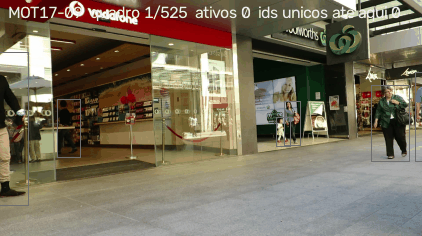

In [4]:
out = Path(OUT_DIR)
mp4 = render_video(result, out / f"{seq.name}.mp4", scale=SCALE, show_gt=SHOW_GT)
gif = render_gif(result, out / f"{seq.name}.gif", scale=0.22, max_frames=80, fps=10, show_gt=SHOW_GT)
txt = result.save_mot_txt(out / f"{seq.name}_tracks.txt")
print("vídeo completo :", mp4, f"({mp4.stat().st_size / 1e6:.1f} MB)")
print("tracks (MOT)   :", txt)
display(Image(filename=str(gif)))

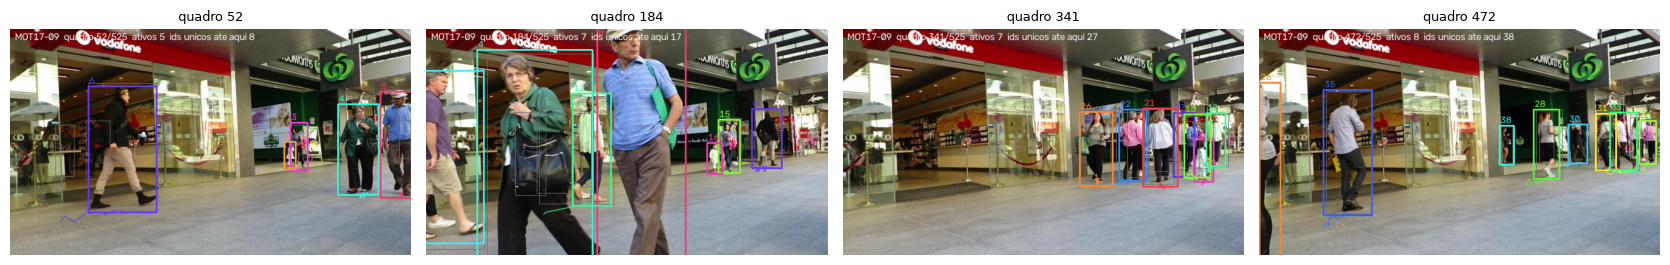

In [5]:
# Quadros ao longo da sequência: o mesmo id mantém a cor
frames = [max(1, int(round(result.n_frames * q))) for q in (0.1, 0.35, 0.65, 0.9)]
imgs = sample_frames(result, frames, scale=0.35, show_gt=SHOW_GT)
fig, axes = plt.subplots(1, len(imgs), figsize=(4.2 * len(imgs), 2.9))
for ax, im, f in zip(axes, imgs, frames):
    ax.imshow(im)
    ax.set_title(f"quadro {f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Quando cada identidade existe

Cada linha é um id emitido, do primeiro ao último quadro em que aparece (ordenados pelo início). Uma pessoa real que reaparece depois de uma oclusão longa
vira **duas linhas** com cores diferentes: é a fragmentação que faz a contagem superestimar.

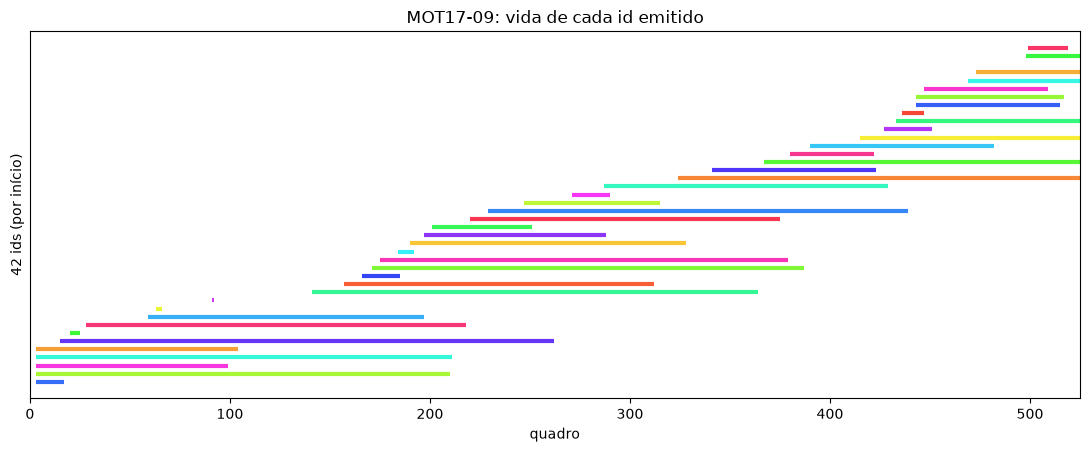

In [6]:
t = result.table
life = t.groupby("id").frame.agg(["min", "max", "count"]).sort_values("min")
fig, ax = plt.subplots(figsize=(11, max(3.0, 0.11 * len(life))))
for y, (tid, r) in enumerate(life.iterrows()):
    rgb = tuple(v / 255 for v in id_color(tid))
    ax.hlines(y, r["min"], r["max"], color=rgb, lw=3)
ax.set_xlabel("quadro")
ax.set_ylabel(f"{len(life)} ids (por início)")
ax.set_yticks([])
ax.set_xlim(0, result.n_frames)
ax.set_title(f"{seq.name}: vida de cada id emitido")
plt.tight_layout()
plt.show()

## Uma sequência sem GT

O mesmo código roda numa sequência qualquer. A pasta `test/` do MOT17 **não tem GT** (só `det/det.txt`): não há métricas, só tracks, contagem e vídeo.

MOT17-01: 300 quadros | detecções públicas (SDP, det/det.txt)
objetos únicos (ids distintos): 72 | com >= 10 quadros: 47 | GT: None
métricas: None


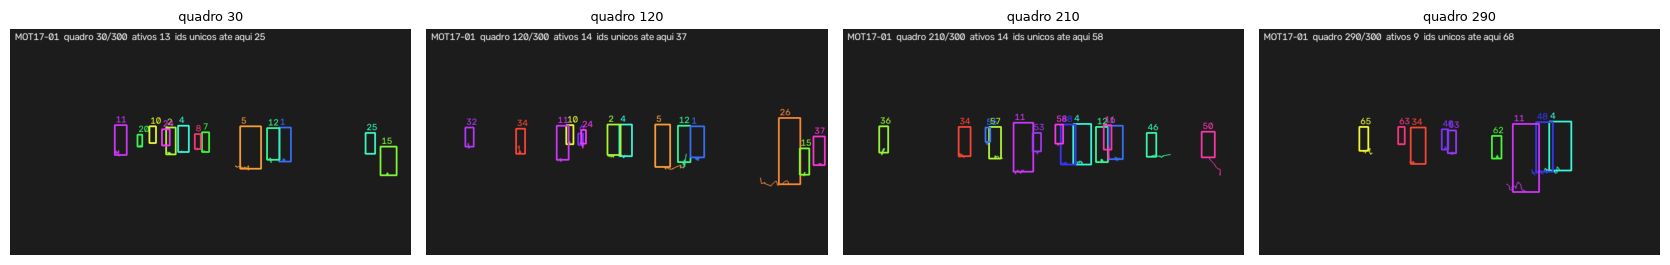

In [7]:
import os
other = "data/MOT17/test/MOT17-01-SDP"
if os.path.exists(other):
    r2 = run_inference(other, max_frames=300)
    c2 = r2.counts()
    print(f"{r2.seq.name}: {r2.n_frames} quadros | {r2.detector_source}")
    print(f"objetos únicos (ids distintos): {c2['ids_unicos']} | com >= 10 quadros: {c2['ids_unicos_com_10+_quadros']} | GT: {c2['ids_gt']}")
    print("métricas:", r2.metrics)
    frames2 = [30, 120, 210, 290]
    fig, axes = plt.subplots(1, 4, figsize=(16.8, 2.9))
    for ax, im, f in zip(axes, sample_frames(r2, frames2, scale=0.35), frames2):
        ax.imshow(im); ax.set_title(f"quadro {f}", fontsize=9); ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("pasta de exemplo não encontrada:", other)

## Limites, para ler os resultados com cuidado

- **A contagem de objetos únicos superestima** (cada fragmentação cria um id novo). Use a coluna "só ids vistos em >= 10 quadros" e, havendo GT, compare com o número real.
- **Sem as imagens, o fundo é vazio.** Com `img1/` presente (neste repositório só nos vídeos de treino do MOT17 extraídos do zip, e não versionadas), o vídeo usa os quadros reais.
- **Sem `det/det.txt` e com imagens**, o notebook usa o Faster R-CNN do torchvision (limiar de score 0,5, NMS próprio, em cache). Esse caminho foi **testado com modelo falso e também rodado em imagens reais** (`detector="torchvision"` no MOT17-09, ~55 s em GPU: 110 ids emitidos, 66 com ≥ 10 quadros, 26 pessoas reais; IDF1 0,449 contra 0,615 com as detecções públicas SDP): é um detector pior, então mais fragmentação.
- Os limiares de score das detecções públicas vêm da Parte 1 (SDP 0,4; FRCNN 0,05; DPM −0,295). Para outro detector, passe `score_threshold=` a `run_inference`.
- O modelo foi treinado com **Δt = 1** quadro; em vídeo a taxa menor ele degrada, sobretudo com câmera móvel (`RELATORY_PART5.md`).
- O IDF1 de uma sequência do MOT17 aqui usa as detecções brutas, sem filtrar as que caem sobre distratores do GT; isso reproduz as Partes 1–5 (IDF1 médio 0,595 com o filtro e 0,596 sem).